# STAT 303 Final Project

**Benchmarking RNN, LSTM and GRU for Multivariate Oil Price Forecasting**

Group Member - Htet Khant Linn | May Mon Thant | Ming Thet Paing

Date - May 23, 2026


## 1. Import Libraries

In [70]:
# library installation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import kagglehub
from kagglehub import KaggleDatasetAdapter
import random
import tensorflow as tf

## 2. Load and Preprocess Data

In [71]:
# importing file from Kaggle

file_path = "oil_geopolitics_dataset_2010_2026.csv"

print("Downloading and loading data from Kaggle...")

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "kavyadhyani/global-oil-prices-and-geopolitical-events",
  file_path,
  )

print("\nData successfully loaded!")

/tmp/ipykernel_1024/1336014778.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'global-oil-prices-and-geopolitical-events' dataset.

Data successfully loaded!


In [72]:
# Setting seed to have consistancy in training

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds locked!")

Random seeds locked!


In [73]:
print(df.head())

         date  brent_price  wti_price  dxy_index        vix  gpr_index  \
0  2010-02-17    76.269997  77.330002  80.379997  21.719999  80.725357   
1  2010-02-18    77.779999  79.059998  80.400002  20.629999  80.725357   
2  2010-02-19    78.190002  79.809998  80.639999  20.020000  80.725357   
3  2010-02-22    78.610001  80.160004  80.510002  19.940001  80.725357   
4  2010-02-23    77.250000  78.860001  80.849998  21.370001  80.725357   

   brent_return  wti_return  brent_lag_1  brent_lag_3  ...  wti_lag_7  \
0      0.007796    0.004155    75.680000    73.050003  ...  71.190002   
1      0.019798    0.022372    76.269997    72.900002  ...  71.889999   
2      0.005271    0.009486    77.779999    75.680000  ...  73.750000   
3      0.005372    0.004385    78.190002    76.269997  ...  74.519997   
4     -0.017301   -0.016218    78.610001    77.779999  ...  75.279999   

   brent_volatility_7d  brent_volatility_30d  wti_volatility_7d  \
0             0.014461              0.019679     

In [74]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4047 entries, 0 to 4046
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  4047 non-null   object 
 1   brent_price           4047 non-null   float64
 2   wti_price             4047 non-null   float64
 3   dxy_index             4047 non-null   float64
 4   vix                   4047 non-null   float64
 5   gpr_index             4047 non-null   float64
 6   brent_return          4047 non-null   float64
 7   wti_return            4047 non-null   float64
 8   brent_lag_1           4047 non-null   float64
 9   brent_lag_3           4047 non-null   float64
 10  brent_lag_7           4047 non-null   float64
 11  wti_lag_1             4047 non-null   float64
 12  wti_lag_3             4047 non-null   float64
 13  wti_lag_7             4047 non-null   float64
 14  brent_volatility_7d   4047 non-null   float64
 15  brent_volatility_30d 

In [75]:
# changing date to Date Format

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

In [76]:
print(df['date'].head())

print(df['date'].tail())

0   2010-02-17
1   2010-02-18
2   2010-02-19
3   2010-02-22
4   2010-02-23
Name: date, dtype: datetime64[ns]
4042   2026-03-06
4043   2026-03-09
4044   2026-03-10
4045   2026-03-11
4046   2026-03-12
Name: date, dtype: datetime64[ns]


In [77]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4047 entries, 0 to 4046
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  4047 non-null   datetime64[ns]
 1   brent_price           4047 non-null   float64       
 2   wti_price             4047 non-null   float64       
 3   dxy_index             4047 non-null   float64       
 4   vix                   4047 non-null   float64       
 5   gpr_index             4047 non-null   float64       
 6   brent_return          4047 non-null   float64       
 7   wti_return            4047 non-null   float64       
 8   brent_lag_1           4047 non-null   float64       
 9   brent_lag_3           4047 non-null   float64       
 10  brent_lag_7           4047 non-null   float64       
 11  wti_lag_1             4047 non-null   float64       
 12  wti_lag_3             4047 non-null   float64       
 13  wti_lag_7         

In [78]:
# selecting features
features = ['brent_price', 'wti_price', 'dxy_index', 'vix', 'gpr_index', 'event_severity']

data = df[features].values

print(data.shape)

(4047, 6)


## 3. Train/Test Split (80% Train, 20% Test)

In [79]:
split_index = int(len(data)*0.8)
print(f"Out of {len(data)} rows, we will use {split_index} rows for training")

training_set = data[:split_index]
test_set = data[split_index:]

Out of 4047 rows, we will use 3237 rows for training


## 4. Feature Scaling

In [80]:
# scaler for all features
sc_features = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc_features.fit_transform(training_set)
test_set_scaled = sc_features.transform(test_set)

print('=== Scaled Training Set ===')
print(training_set_scaled.shape)
print()

print('=== Scaled Test Set ===')
print(test_set_scaled.shape)
print()

=== Scaled Training Set ===
(3237, 6)

=== Scaled Test Set ===
(810, 6)



In [81]:
sc_prices = MinMaxScaler(feature_range=(0, 1))
# fit only on the first two columns (Brent and WTI)
sc_prices.fit(training_set[:, 0:2])


MinMaxScaler()

## 5. Sequence Generation

In [82]:
window_size = 20

def create_sequences(dataset, window):
  X, y = [], []
  for i in range(window, len(dataset)):
    X.append(dataset[i-window:i,:])
    y.append(dataset[i, 0:2])
  return np.array(X), np.array(y)

X_train, y_train = create_sequences(training_set_scaled, window_size)
X_test, y_test = create_sequences(test_set_scaled, window_size)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(3217, 20, 6)
(3217, 2)
(790, 20, 6)
(790, 2)


In [83]:
num_features = X_train.shape[2]

print(f"Number of Features: {num_features}")

Number of Features: 6


## 6. Creating Model Building Function

In [84]:
def build_model(model_type, window, n_features):
  model = Sequential()

  if model_type == 'RNN':
    model.add(SimpleRNN(units=64, return_sequences=True, input_shape=(window, n_features)))
    model.add(Dropout(0.2))
    model.add(SimpleRNN(units=32, return_sequences=False))

  elif model_type == 'LSTM':
    model.add(LSTM(units=64, return_sequences=True, input_shape=(window, n_features)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=32, return_sequences=False))

  elif model_type == 'GRU':
    model.add(GRU(units=64, return_sequences=True, input_shape=(window, n_features)))
    model.add(Dropout(0.2))
    model.add(GRU(units=32, return_sequences=False))

  model.add(Dense(units=2)) # 2 units for predicting both Brent and WTI
  model.compile(optimizer='adam', loss='mean_squared_error')

  return model

## 7. Training and Evaluation Loop

In [85]:
model_architectures = ['RNN', 'LSTM', 'GRU']
results = {}

# Increased patience from 10 to 25 for tuning
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for arch in model_architectures:
  print(f" === Training {arch} Model ===")
  model = build_model(arch, window_size, num_features)

  history = model.fit(X_train, y_train, epochs=50, batch_size = 32,
                      validation_split=0.1, callbacks=[early_stop], verbose=1)

  predictions_scaled = model.predict(X_test)
  predictions_real = sc_prices.inverse_transform(predictions_scaled)

  results[arch] = {
      'history' : history.history,
      'predictions' : predictions_real
  }

 === Training RNN Model ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.0304 - val_loss: 0.0151
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0045 - val_loss: 0.0141
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0028 - val_loss: 0.0102
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - val_loss: 0.0088
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 0.0094
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_loss: 0.0075
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0059
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0047
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0040
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.5673e-04 - val_loss: 0.0049
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.4111e-04 - val_loss: 0.0038
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.380

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0128 - val_loss: 0.0103
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - val_loss: 0.0085
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0068
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0041
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.4722e-04 - val_loss: 0.0031
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.6659e-04 - val_loss: 0.0054
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.7228e-04 - val_loss: 0.0043
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.8606e-04 - val_loss: 0.0043
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.8055e-04 - val_loss: 0.0055
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.2904e-04 - val_loss: 0.0060
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.2910e-04 - val_loss: 0.0045
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - los

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0246 - val_loss: 0.0126
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 0.0080
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0060
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0055
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.4978e-04 - val_loss: 0.0047
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.2370e-04 - val_loss: 0.0040
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.1967e-04 - val_loss: 0.0036
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.4400e-04 - val_loss: 0.0039
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.1164e-04 - val_loss: 0.0038
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6742e-04 - val_loss: 0.0036
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.6896e-04 - val_loss: 0.0037
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - 

In [86]:
print('=== Printing Result ===')

print(results)

=== Printing Result ===
{'RNN': {'history': {'loss': [0.030447501689195633, 0.0044862753711640835, 0.0027956657577306032, 0.001997212180867791, 0.0017353983130306005, 0.0015199435874819756, 0.0012778176460415125, 0.001120906788855791, 0.001067630248144269, 0.0009567306260578334, 0.0009411108330823481, 0.0008380117360502481, 0.0007595575298182666, 0.0007599464734084904, 0.0008184469770640135, 0.0006501348689198494, 0.0006915180711075664, 0.0006910955999046564, 0.0006464309408329427, 0.0006606276147067547, 0.0006322111003100872, 0.000603355816565454, 0.0005875516799278557, 0.0005904756253585219, 0.0005597926792688668, 0.000506740587297827, 0.0005127251497469842, 0.0005074423388577998, 0.0005432920879684389, 0.0005423049442470074, 0.0004973235190846026, 0.0005257743177935481, 0.0005277997115626931, 0.0005067776655778289, 0.0005053337663412094, 0.0004458570037968457, 0.0005341050564311445, 0.000508682569488883, 0.000476285902550444, 0.00047725450713187456, 0.00046783991274423897, 0.0004221

In [87]:
# get the actual real dollar prices for the test set

actual_prices = sc_prices.inverse_transform(y_test)
actual_brent = actual_prices[:, 0]
actual_wti = actual_prices[:, 1]

## 8. Comparative Visualization

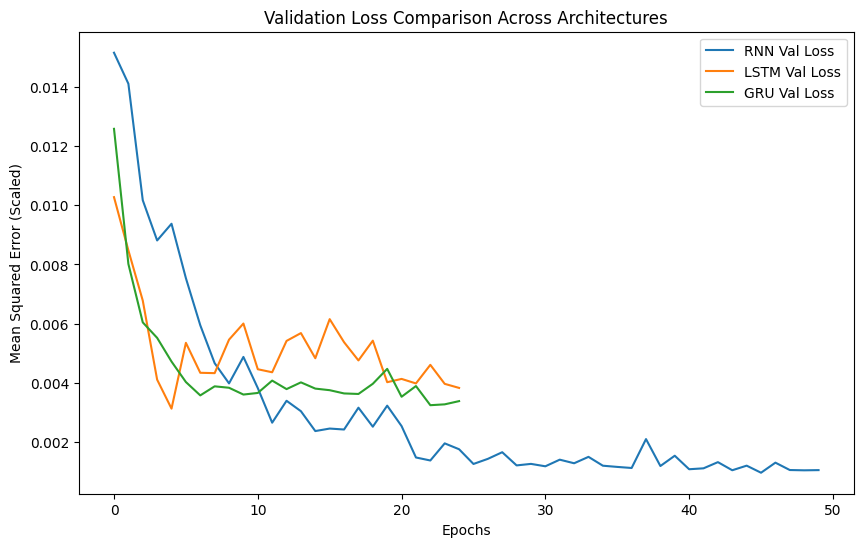

In [88]:
# Plot 1: Validation Loss Comparison (Which model learned best?)

plt.figure(figsize=(10, 6))
for arch in model_architectures:
    plt.plot(results[arch]['history']['val_loss'], label=f'{arch} Val Loss')

plt.title('Validation Loss Comparison Across Architectures')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Scaled)')
plt.legend()

plt.savefig('validation_loss_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('validation_loss_comparison.jpg', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

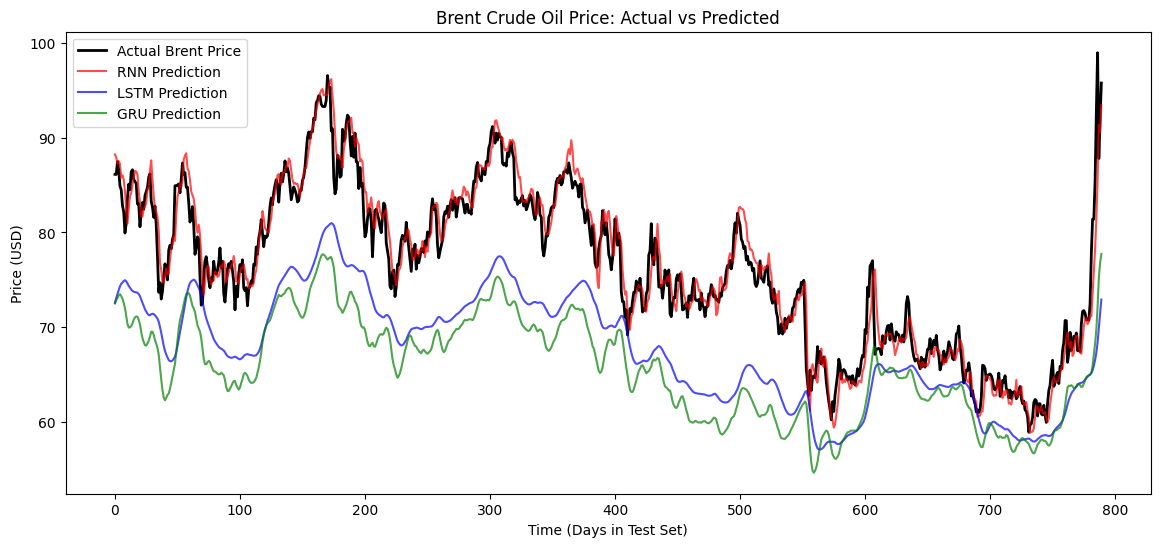

In [89]:
# Plot 2: Brent Price Predictions

plt.figure(figsize=(14, 6))
plt.plot(actual_brent, label='Actual Brent Price', color='black', linewidth=2)
for arch, colors in zip(model_architectures, ['red', 'blue', 'green']):
    plt.plot(results[arch]['predictions'][:, 0], label=f'{arch} Prediction', color=colors, alpha=0.7)

plt.title('Brent Crude Oil Price: Actual vs Predicted')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price (USD)')
plt.legend()

plt.savefig('brent_price_predictions.pdf', dpi=300, bbox_inches='tight')
plt.savefig('brent_price_predictions.jpg', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

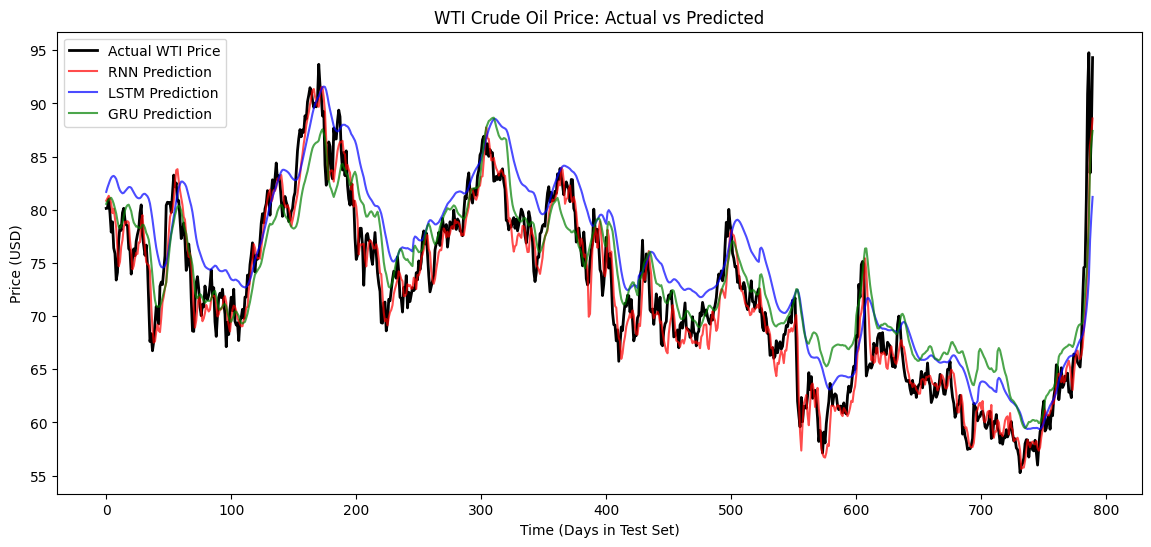

In [90]:
# Plot 3: WTI Price Predictions

plt.figure(figsize=(14, 6))
plt.plot(actual_wti, label='Actual WTI Price', color='black', linewidth=2)
for arch, colors in zip(model_architectures, ['red', 'blue', 'green']):
    plt.plot(results[arch]['predictions'][:, 1], label=f'{arch} Prediction', color=colors, alpha=0.7)

plt.title('WTI Crude Oil Price: Actual vs Predicted')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price (USD)')
plt.legend()

plt.savefig('wti_price_predictions.pdf', dpi=300, bbox_inches='tight')
plt.savefig('wti_price_predictions.jpg', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

## 9. Quantitative Scoreboard

In [91]:
print("\n=== FINAL PERFORMANCE SCOREBOARD ===")

for arch in model_architectures:
  pred_brent = results[arch]['predictions'][:, 0]
  pred_wti = results[arch]['predictions'][:, 1]


  brent_rmse = math.sqrt(mean_squared_error(actual_brent, pred_brent))
  brent_mae = mean_absolute_error(actual_brent, pred_brent)


  wti_rmse = math.sqrt(mean_squared_error(actual_wti, pred_wti))
  wti_mae = mean_absolute_error(actual_wti, pred_wti)

  # print(f"\n{arch} Performance:")
  # print(f"  Brent - RMSE: ${brent_rmse:.2f} | MAE: ${brent_mae:.2f}")
  # print(f"  WTI   - RMSE: ${wti_rmse:.2f} | MAE: ${wti_mae:.2f}")


  print(f"\n{arch} Performance:")
  print(f"  Brent - RMSE: ${brent_rmse:.2f} | MAE: ${brent_mae:.2f} | MAPE: {np.mean(np.abs((actual_brent - pred_brent)/actual_brent)):.2%}")
  print(f"  WTI   - RMSE: ${wti_rmse:.2f} | MAE: ${wti_mae:.2f} | MAPE: {np.mean(np.abs((actual_wti - pred_wti)/actual_wti)):.2%}")



=== FINAL PERFORMANCE SCOREBOARD ===

RNN Performance:
  Brent - RMSE: $2.08 | MAE: $1.52 | MAPE: 1.99%
  WTI   - RMSE: $2.18 | MAE: $1.61 | MAPE: 2.21%

LSTM Performance:
  Brent - RMSE: $9.39 | MAE: $8.48 | MAPE: 10.80%
  WTI   - RMSE: $4.37 | MAE: $3.56 | MAPE: 5.02%

GRU Performance:
  Brent - RMSE: $11.32 | MAE: $10.45 | MAPE: 13.33%
  WTI   - RMSE: $3.72 | MAE: $2.97 | MAPE: 4.26%
